# Multi-Season Joint Fit (33-dim prototype)

Shared phi(14) + gamma(3) across 4 seasons, per-season beta(4×4).
Warm-started from single-season L-BFGS-B fits.
Goal: anchor phi/gamma across seasons to resolve identifiability.


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

import time, json, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

import mlflow
mlflow.set_tracking_uri("sqlite:///" + str(Path("../outputs/mlruns/mlflow.db").resolve()))
mlflow.set_experiment("hira_calibration_multi_season")

from kt_data import HIRA_AGE_GROUPS, SUDOGWON_SIDO_CODES
from kt_epimodel_hira.calibration.hira_target import (
    load_hira_target_by_age, simulation_to_hira_by_age, poisson_log_likelihood,
)
from kt_epimodel_hira.calibration.simple_model import (
    build_aggregated_inputs, estimate_initial_infected_from_hira, simulate_aggregated,
)
from kt_epimodel_hira.calibration.loss import make_loss_function_by_age
from kt_epimodel_hira.calibration.param_vector import (
    get_param_names, vector_to_params, N_VECTOR,
)
from kt_epimodel_hira.model.parameters import (
    CalibrationParameters, DiseaseParameters, ModelParameters,
)

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150,
                     "axes.unicode_minus": False, "font.family": "DejaVu Sans"})

OUTDIR = Path("../outputs/calibration"); OUTDIR.mkdir(parents=True, exist_ok=True)
SEASONS = ["2017-2018", "2018-2019", "2019-2020", "2022-2023"]
N_SEASONS = len(SEASONS)
N_SHARED = 17  # 14 phi + 3 gamma
N_PER_SEASON = 4  # beta_h/w/s/o
N_TOTAL = N_SHARED + N_PER_SEASON * N_SEASONS  # 33
MAX_ITER = 1000

print(f"Multi-season joint fit: {N_TOTAL}-dim, {N_SEASONS} seasons, maxiter={MAX_ITER}")


2026/05/28 11:02:05 INFO mlflow.tracking.fluent: Experiment with name 'hira_calibration_multi_season' does not exist. Creating a new experiment.


Multi-season joint fit: 33-dim, 4 seasons, maxiter=1000


In [2]:
# Warm-start from single-season fits
single_vecs = {}
for season in SEASONS:
    path = OUTDIR / f"calib_{season}_LBFGS_age_gamma.json"
    with open(path) as f:
        d = json.load(f)
    single_vecs[season] = np.array(d["vector"])
    print(f"{season}: NLL={d['nll']:.0f}")

# Average phi and gamma across seasons
phi_all = np.array([single_vecs[s][4:18] for s in SEASONS])
gamma_all = np.array([single_vecs[s][18:21] for s in SEASONS])

phi_avg = phi_all.mean(axis=0)
gamma_avg = gamma_all.mean(axis=0)

print(f"\nPhi avg (14): {np.round(phi_avg, 3)}")
print(f"Gamma avg (child/adult/elder): {np.round(gamma_avg, 4)}")
print(f"\nSingle-season phi CV: {(phi_all.std(0)/phi_all.mean(0)*100).mean():.1f}%")
print(f"Single-season gamma CV: {(gamma_all.std(0)/np.maximum(gamma_all.mean(0),1e-10)*100)}")

# Build 33-dim warm-start vector
# Layout: [phi(14), gamma(3), beta_s0(4), beta_s1(4), beta_s2(4), beta_s3(4)]
init_33 = np.zeros(N_TOTAL)
init_33[:14] = phi_avg
init_33[14:17] = gamma_avg
for i, s in enumerate(SEASONS):
    init_33[17 + i*4 : 21 + i*4] = single_vecs[s][:4]  # beta from single fit
    print(f"  {s} beta init: {single_vecs[s][:4].round(4)}")

print(f"\n33-dim init vector: {init_33.round(4)}")


2017-2018: NLL=-8840613
2018-2019: NLL=-7450722
2019-2020: NLL=-6887506
2022-2023: NLL=-5401038

Phi avg (14): [2.107 1.91  0.573 0.686 0.63  0.644 0.71  0.737 0.63  0.539 0.581 0.583
 0.587 0.568]
Gamma avg (child/adult/elder): [0.4026 0.0826 0.111 ]

Single-season phi CV: 42.7%
Single-season gamma CV: [26.70376731 27.04908847 69.59152973]
  2017-2018 beta init: [0.1558 0.4073 0.001  0.0022]
  2018-2019 beta init: [0.2044 0.001  0.001  0.001 ]
  2019-2020 beta init: [0.1992 0.1382 0.001  0.0011]
  2022-2023 beta init: [0.0493 0.001  0.2339 0.161 ]

33-dim init vector: [2.1068e+00 1.9100e+00 5.7280e-01 6.8630e-01 6.2970e-01 6.4420e-01
 7.0990e-01 7.3730e-01 6.3040e-01 5.3930e-01 5.8080e-01 5.8280e-01
 5.8710e-01 5.6850e-01 4.0260e-01 8.2600e-02 1.1100e-01 1.5580e-01
 4.0730e-01 1.0000e-03 2.2000e-03 2.0440e-01 1.0000e-03 1.0000e-03
 1.0000e-03 1.9920e-01 1.3820e-01 1.0000e-03 1.1000e-03 4.9300e-02
 1.0000e-03 2.3390e-01 1.6100e-01]


In [3]:
# Build per-season loss closures (reuse existing infrastructure)
inputs = build_aggregated_inputs()
pop_15 = inputs["pop_15"].flatten()

season_losses = {}
season_targets = {}
season_seeds = {}

for season in SEASONS:
    target = load_hira_target_by_age(
        season, sido_codes=list(SUDOGWON_SIDO_CODES),
        first_peak_only=True, first_peak_end_week=26,
    )
    season_targets[season] = target

    seed = estimate_initial_infected_from_hira(
        season, pop_15, sido_codes=list(SUDOGWON_SIDO_CODES),
        gamma_15_assumed=CalibrationParameters().gamma_15,
    )
    season_seeds[season] = seed

    loss_fn = make_loss_function_by_age(
        target, inputs, ModelParameters(),
        seed_total=float(seed.sum()),
        seed_by_age=seed, seed_e_factor=0.5,
        initial_immunity=0.3, initial_vaccinated_fraction=0.0,
        t_span=(0.0, 364.0), verbose=False,
    )
    season_losses[season] = loss_fn
    print(f"{season}: loss closure ready, seed_total={seed.sum():.0f}")

print(f"\nAll {len(season_losses)} season loss functions created.")


2017-2018: loss closure ready, seed_total=1472
2018-2019: loss closure ready, seed_total=1645
2019-2020: loss closure ready, seed_total=1611
2022-2023: loss closure ready, seed_total=2270

All 4 season loss functions created.


In [4]:
# Multi-season loss: 33-dim -> sum of 4 season NLLs
def multi_season_loss(vec_33, return_breakdown=False):
    phi_14 = vec_33[:14]
    gamma_3 = vec_33[14:17]
    total = 0.0
    breakdown = {}
    for i, season in enumerate(SEASONS):
        beta_4 = vec_33[17 + i*4 : 21 + i*4]
        vec_21 = np.concatenate([beta_4, phi_14, gamma_3])
        nll = season_losses[season](vec_21)
        breakdown[season] = nll
        total += nll
    if return_breakdown:
        return total, breakdown
    return total

# Sanity: warm-start NLL should be close to sum of single-season final NLLs
init_nll, init_breakdown = multi_season_loss(init_33, return_breakdown=True)
single_nll_sum = sum(
    json.load(open(OUTDIR / f"calib_{s}_LBFGS_age_gamma.json"))["nll"]
    for s in SEASONS
)

print(f"Warm-start total NLL: {init_nll:,.0f}")
print(f"Single-season sum:    {single_nll_sum:,.0f}")
print(f"Delta:                {init_nll - single_nll_sum:+,.0f} "
      f"({(init_nll - single_nll_sum)/abs(single_nll_sum)*100:+.2f}%)")
print(f"\nBreakdown:")
for s, nll in init_breakdown.items():
    single_nll = json.load(open(OUTDIR / f"calib_{s}_LBFGS_age_gamma.json"))["nll"]
    print(f"  {s}: joint={nll:,.0f}  single={single_nll:,.0f}  delta={nll-single_nll:+,.0f}")


Warm-start total NLL: -16,766,738
Single-season sum:    -28,579,879
Delta:                +11,813,141 (+41.33%)

Breakdown:
  2017-2018: joint=-5,693,550  single=-8,840,613  delta=+3,147,064
  2018-2019: joint=-4,022,256  single=-7,450,722  delta=+3,428,467
  2019-2020: joint=-6,462,749  single=-6,887,506  delta=+424,757
  2022-2023: joint=-588,184  single=-5,401,038  delta=+4,812,853


In [5]:
# L-BFGS-B optimization (33-dim)
bounds_33 = (
    [(0.1, 5.0)] * 14 +                          # phi
    [(0.10, 0.60), (0.05, 0.40), (0.03, 0.50)] + # gamma (elder lower bound expanded)
    [(0.001, 0.30)] * (4 * N_SEASONS)             # beta per season
)

nll_history = []
eval_count = [0]

def loss_logged(vec):
    eval_count[0] += 1
    nll = multi_season_loss(vec)
    nll_history.append(nll)
    if eval_count[0] % 50 == 0:
        print(f"  eval {eval_count[0]:>5}: NLL = {nll:,.0f}")
    return nll

print(f"Starting L-BFGS-B, {N_TOTAL}-dim, maxiter={MAX_ITER}")
t0 = time.perf_counter()

with mlflow.start_run(run_name="multi_season_joint_v1"):
    mlflow.log_params({
        "method": "L-BFGS-B", "maxiter": MAX_ITER,
        "dimension": N_TOTAL, "n_seasons": N_SEASONS,
        "warm_start": "single_season_avg",
    })

    sol = minimize(
        loss_logged, init_33,
        method="L-BFGS-B", bounds=bounds_33,
        options={"maxiter": MAX_ITER, "disp": True},
    )

    wall = time.perf_counter() - t0
    mlflow.log_metric("nll_initial", init_nll)
    mlflow.log_metric("nll_final", sol.fun)
    mlflow.log_metric("n_evals", eval_count[0])
    mlflow.log_metric("wall_time_min", wall / 60)

print(f"\n=== Done ===")
print(f"Wall time: {wall/60:.1f} min")
print(f"Evals: {eval_count[0]}, success: {sol.success}")
print(f"NLL: {init_nll:,.0f} -> {sol.fun:,.0f} ({init_nll - sol.fun:+,.0f})")
print(f"Message: {sol.message}")


Starting L-BFGS-B, 33-dim, maxiter=1000


/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_4955/3178634826.py:29: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  sol = minimize(


  eval    50: NLL = 16,980,056


  eval   100: NLL = -3,656,955


  eval   150: NLL = -21,904,282


...

  eval  2850: NLL = -28,469,365


  eval  2900: NLL = -28,469,430


  eval  2950: NLL = -28,460,439


  eval  3000: NLL = -28,469,430



=== Done ===
Wall time: 281.0 min
Evals: 3026, success: True
NLL: -16,766,738 -> -28,469,430 (+11,702,692)
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [6]:
# Extract fitted parameters
best = sol.x
phi_fit = best[:14]
gamma_fit = best[14:17]
betas_fit = {SEASONS[i]: best[17+i*4:21+i*4] for i in range(N_SEASONS)}

_, final_breakdown = multi_season_loss(best, return_breakdown=True)

print("=== Shared parameters ===")
phi_names = [f"phi_{a}" for a in range(15) if a != 5]
for n, v in zip(phi_names, phi_fit):
    print(f"  {n:>8}: {v:.4f}")
print(f"  gamma_child: {gamma_fit[0]:.4f}")
print(f"  gamma_adult: {gamma_fit[1]:.4f}")
print(f"  gamma_elder: {gamma_fit[2]:.4f}")

print(f"\n=== Per-season beta ===")
print(f"{'season':>12} {'beta_h':>8} {'beta_w':>8} {'beta_s':>8} {'beta_o':>8} {'NLL':>12}")
for s in SEASONS:
    b = betas_fit[s]
    print(f"{s:>12} {b[0]:>8.4f} {b[1]:>8.4f} {b[2]:>8.4f} {b[3]:>8.4f} {final_breakdown[s]:>12,.0f}")

# Beta CV across seasons
print(f"\n=== Beta CV across seasons ===")
for ch_i, ch in enumerate(["h", "w", "s", "o"]):
    vals = [betas_fit[s][ch_i] for s in SEASONS]
    cv = np.std(vals) / max(np.mean(vals), 1e-10) * 100
    print(f"  beta_{ch}: mean={np.mean(vals):.4f} CV={cv:.1f}%")


=== Shared parameters ===
     phi_0: 1.4933
     phi_1: 1.0600
     phi_2: 0.7826
     phi_3: 1.2268
     phi_4: 0.1169
     phi_6: 0.7137
     phi_7: 0.2001
     phi_8: 0.2450
     phi_9: 0.1213
    phi_10: 0.6249
    phi_11: 0.6743
    phi_12: 0.1002
    phi_13: 0.1104
    phi_14: 0.1135
  gamma_child: 0.3362
  gamma_adult: 0.0892
  gamma_elder: 0.3198

=== Per-season beta ===
      season   beta_h   beta_w   beta_s   beta_o          NLL
   2017-2018   0.1256   0.1155   0.0032   0.1856   -8,770,228
   2018-2019   0.2740   0.0313   0.0339   0.0594   -7,454,211
   2019-2020   0.2518   0.1215   0.0242   0.0647   -6,855,480
   2022-2023   0.0122   0.1570   0.0526   0.1351   -5,389,512

=== Beta CV across seasons ===
  beta_h: mean=0.1659 CV=63.4%
  beta_w: mean=0.1063 CV=43.4%
  beta_s: mean=0.0285 CV=62.6%
  beta_o: mean=0.1112 CV=47.0%


In [7]:
# Identifiability comparison: single-season vs joint
print("=== Identifiability improvement ===")
print(f"\nPhi:")
print(f"  Single-season CV (mean across 14 phi): "
      f"{(phi_all.std(0)/phi_all.mean(0)*100).mean():.1f}%")
print(f"  Joint fit: single shared value per phi (CV=0% by construction)")
print(f"  Phi range: [{phi_fit.min():.3f}, {phi_fit.max():.3f}]")

print(f"\nGamma:")
for gi, gn in enumerate(["child", "adult", "elder"]):
    single_cv = gamma_all[:, gi].std() / max(gamma_all[:, gi].mean(), 1e-10) * 100
    print(f"  gamma_{gn}: single CV={single_cv:.1f}% -> joint={gamma_fit[gi]:.4f}")

print(f"\nBeta (single vs joint):")
for ch_i, ch in enumerate(["h", "w", "s", "o"]):
    single_vals = [single_vecs[s][ch_i] for s in SEASONS]
    joint_vals = [betas_fit[s][ch_i] for s in SEASONS]
    cv_single = np.std(single_vals) / max(np.mean(single_vals), 1e-10) * 100
    cv_joint = np.std(joint_vals) / max(np.mean(joint_vals), 1e-10) * 100
    print(f"  beta_{ch}: single CV={cv_single:.1f}% -> joint CV={cv_joint:.1f}%")


=== Identifiability improvement ===

Phi:
  Single-season CV (mean across 14 phi): 42.7%
  Joint fit: single shared value per phi (CV=0% by construction)
  Phi range: [0.100, 1.493]

Gamma:
  gamma_child: single CV=26.7% -> joint=0.3362
  gamma_adult: single CV=27.0% -> joint=0.0892
  gamma_elder: single CV=69.6% -> joint=0.3198

Beta (single vs joint):
  beta_h: single CV=41.0% -> joint CV=63.4%
  beta_w: single CV=121.2% -> joint CV=43.4%
  beta_s: single CV=170.3% -> joint CV=62.6%
  beta_o: single CV=167.1% -> joint CV=47.0%


In [8]:
# R0 per season
def compute_R0_ngm(cal, disease, inputs_dict, initial_immunity=0.3):
    pop = inputs_dict["pop_15"].flatten()
    N_safe = np.maximum(pop, 1e-10)
    matrices = inputs_dict["matrices"]
    rho = inputs_dict["rho"].flatten()
    sf = disease.seasonal_factor(disease.seasonality_peak_day)
    C_eff = np.zeros((15, 15))
    C_eff += cal.beta_h * matrices["C_home"]
    C_eff[:4, :4] += cal.beta_s * matrices["C_school"][:4, :4]
    rho_ok = (rho > 0).astype(float)
    for a in range(4, 14):
        C_eff[a, :] += cal.beta_w * matrices["C_work"][a, :] * rho[a] * rho_ok
    C_eff += cal.beta_o * matrices["C_other"]
    K = ((1-initial_immunity) * sf / disease.gamma) * \
        np.diag(pop) @ np.diag(cal.phi) @ C_eff @ np.diag(1.0/N_safe)
    return float(np.max(np.real(np.linalg.eigvals(K))))

dis = DiseaseParameters()

# Age bias per season
print(f"{'season':>12} {'R0':>6} {'0-5':>7} {'6-11':>7} {'12-17':>7} {'18-44':>7} {'45-64':>7} {'65+':>7}")
print("-" * 72)

age_bias = {}
for i, s in enumerate(SEASONS):
    beta_4 = betas_fit[s]
    vec_21 = np.concatenate([beta_4, phi_fit, gamma_fit])
    cal = vector_to_params(vec_21)
    R0 = compute_R0_ngm(cal, dis, inputs)

    seed = season_seeds[s]
    params = ModelParameters().with_calibration(cal)
    sim = simulate_aggregated(
        params, inputs, seed_total=float(seed.sum()),
        seed_by_age=seed, seed_e_factor=0.5,
        initial_immunity=0.3, initial_vaccinated_fraction=0.0, t_span=(0.0, 364.0),
    )
    daily_inc = sim.daily_new_infection_by_age()
    pred = simulation_to_hira_by_age(daily_inc, cal.gamma_15,
                                      n_weeks=season_targets[s]["n_weeks"])

    row = f"{s:>12} {R0:>6.3f}"
    ratios = {}
    for ag in HIRA_AGE_GROUPS:
        obs_pk = float(season_targets[s]["hira_counts"][ag].max())
        pred_pk = float(pred[ag].max())
        r = pred_pk / max(obs_pk, 1)
        ratios[ag] = r
        row += f" {r:>7.2f}"
    age_bias[s] = ratios
    print(row)


      season     R0     0-5    6-11   12-17   18-44   45-64     65+
------------------------------------------------------------------------


   2017-2018  1.911    0.57    0.54    0.88    0.77    0.50    0.31


   2018-2019  2.022    0.85    0.80    1.29    0.66    0.68    0.69


   2019-2020  1.874    0.73    0.71    1.49    0.82    0.86    0.58


   2022-2023  1.986    1.00    0.50    0.70    0.56    0.94    0.65


In [9]:
# Bound hits
print("=== Bound hits (within 2% of range) ===")
lo_arr = np.array([b[0] for b in bounds_33])
hi_arr = np.array([b[1] for b in bounds_33])
span = hi_arr - lo_arr

# Shared params
labels_33 = phi_names + ["gamma_child", "gamma_adult", "gamma_elder"]
for i, s in enumerate(SEASONS):
    labels_33 += [f"beta_h_{s}", f"beta_w_{s}", f"beta_s_{s}", f"beta_o_{s}"]

hits_lo, hits_hi = [], []
for i in range(N_TOTAL):
    if (best[i] - lo_arr[i]) / span[i] < 0.02:
        hits_lo.append(f"{labels_33[i]}=LO({best[i]:.4f})")
    elif (hi_arr[i] - best[i]) / span[i] < 0.02:
        hits_hi.append(f"{labels_33[i]}=HI({best[i]:.4f})")

print(f"  Lower: {', '.join(hits_lo) if hits_lo else '(none)'}")
print(f"  Upper: {', '.join(hits_hi) if hits_hi else '(none)'}")


=== Bound hits (within 2% of range) ===
  Lower: phi_4=LO(0.1169), phi_9=LO(0.1213), phi_12=LO(0.1002), phi_13=LO(0.1104), phi_14=LO(0.1135), beta_s_2017-2018=LO(0.0032)
  Upper: (none)


saved multi_season_joint_fit.png


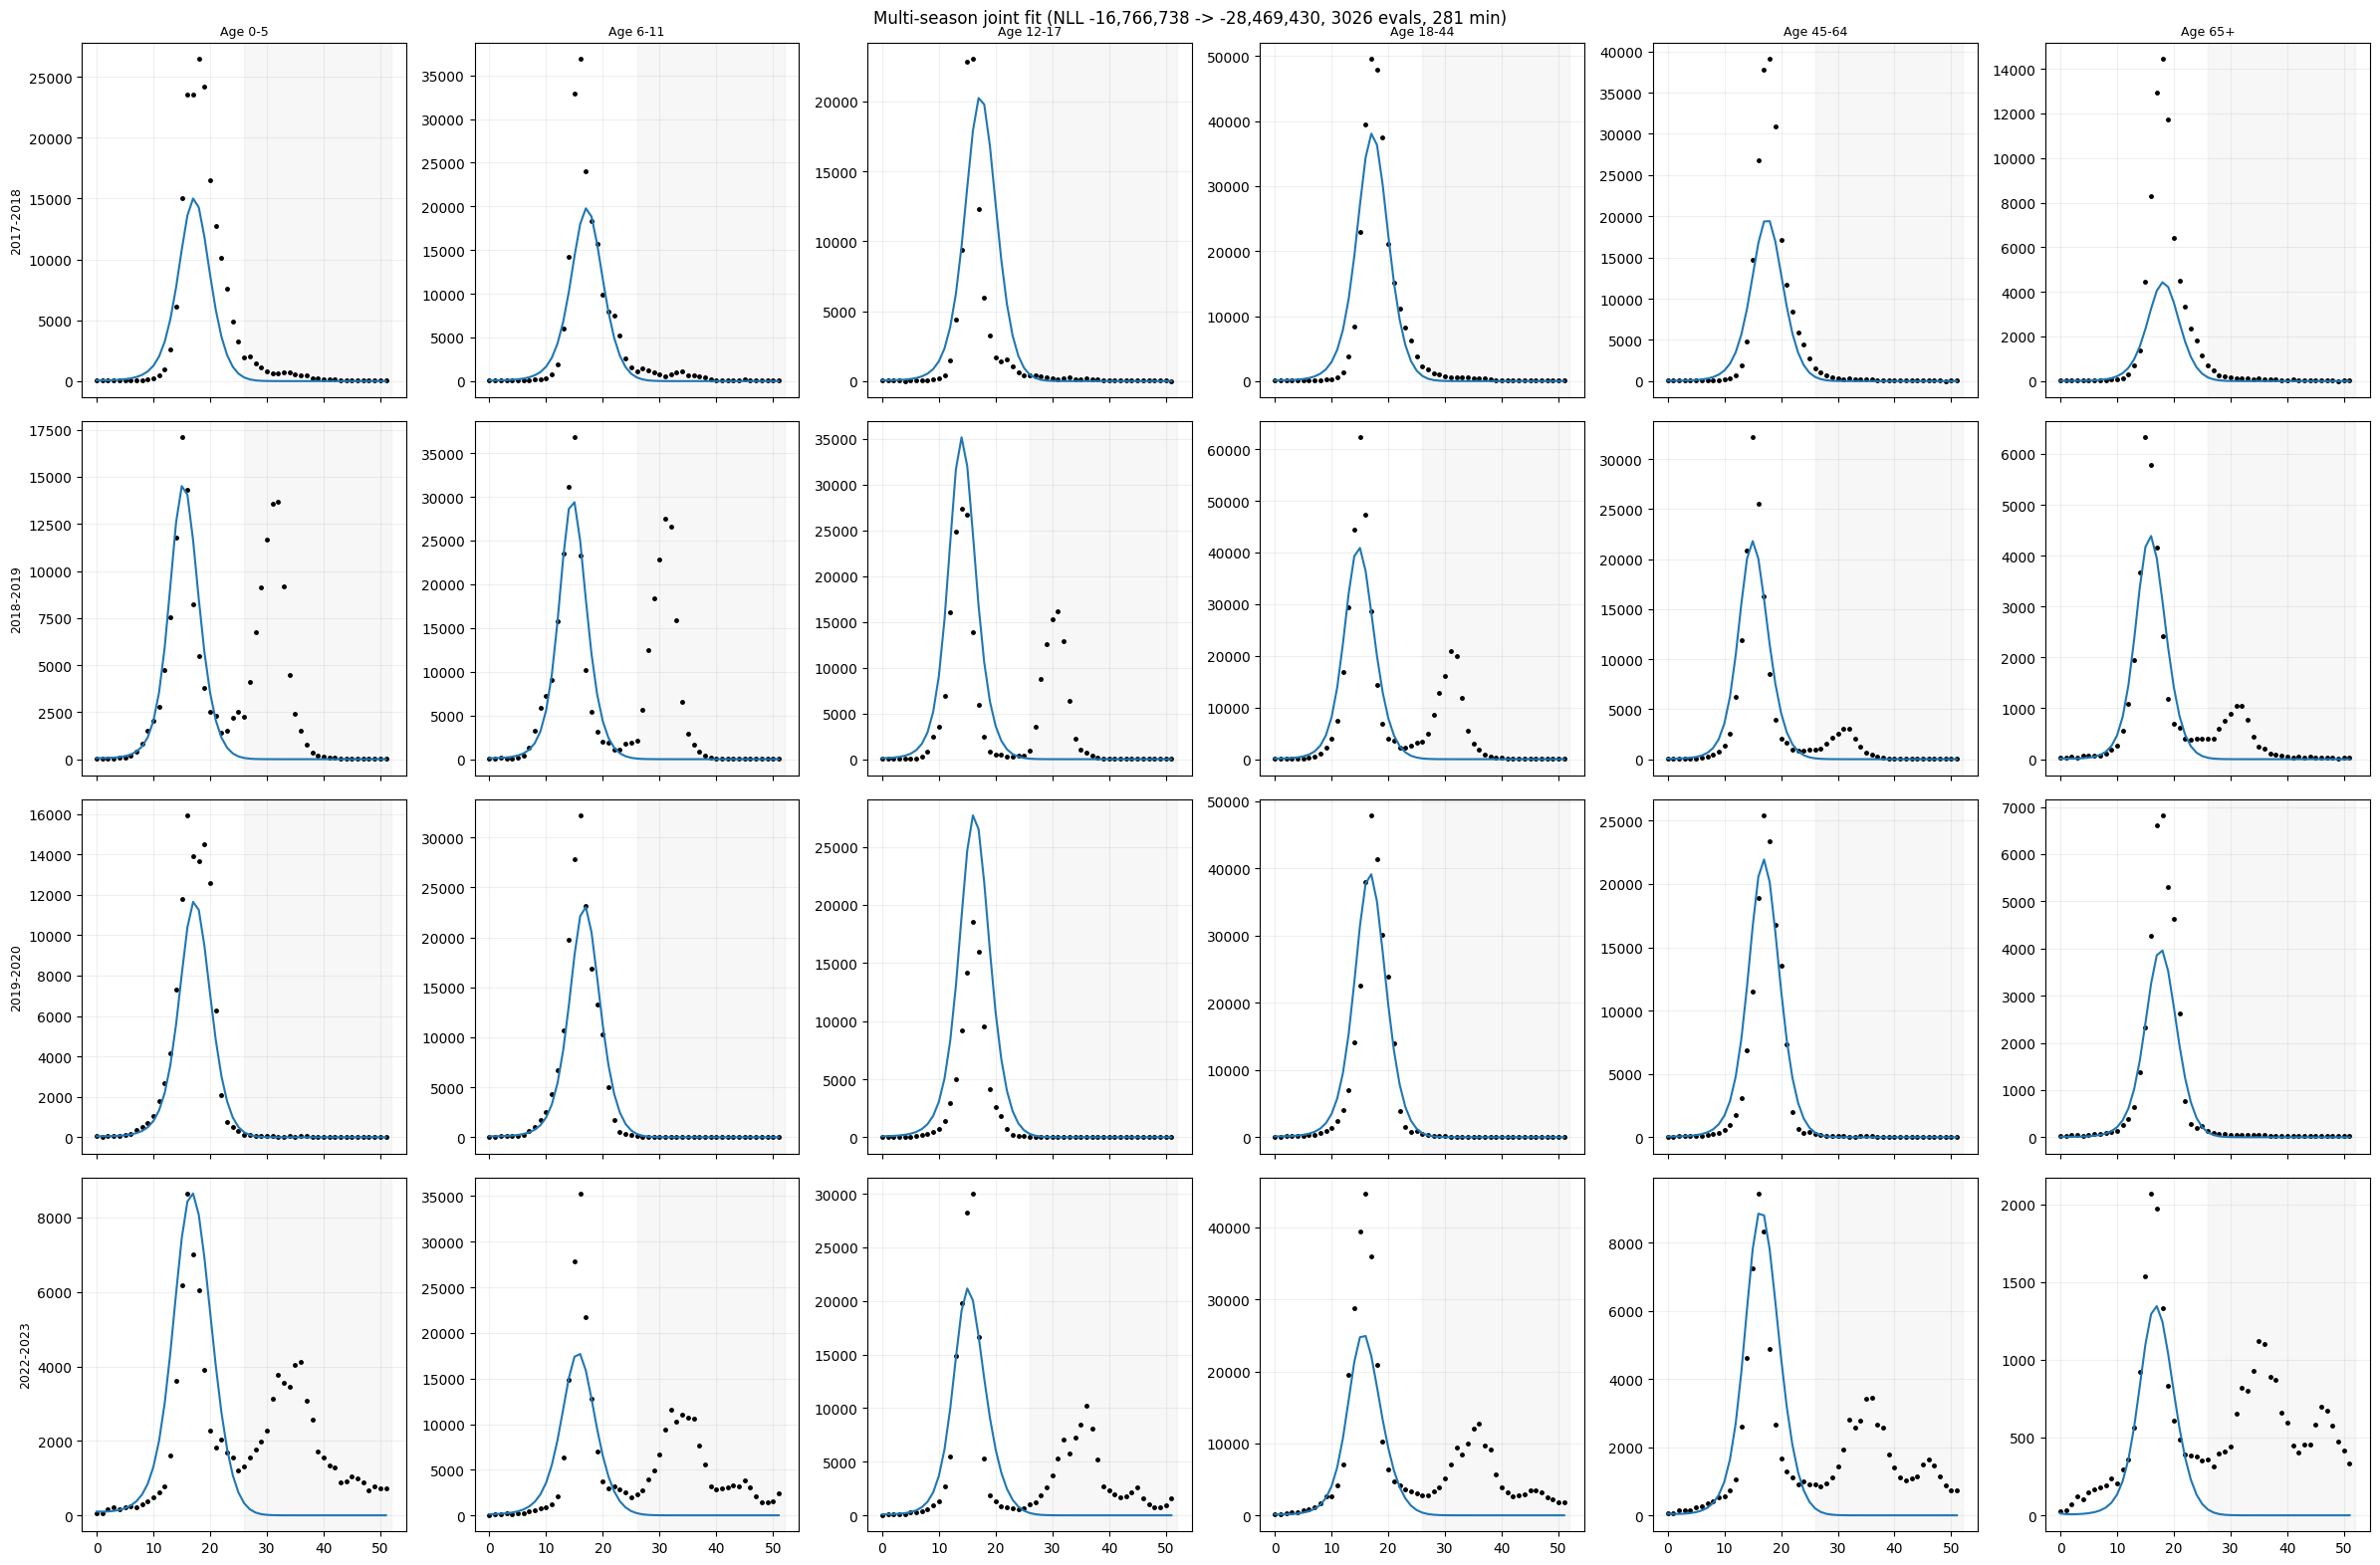

In [10]:
# Fit curves (4 seasons × 6 age groups)
fig, axes = plt.subplots(4, 6, figsize=(24, 16), sharex=True)

for row_i, s in enumerate(SEASONS):
    beta_4 = betas_fit[s]
    vec_21 = np.concatenate([beta_4, phi_fit, gamma_fit])
    cal = vector_to_params(vec_21)
    params = ModelParameters().with_calibration(cal)
    seed = season_seeds[s]
    sim = simulate_aggregated(
        params, inputs, seed_total=float(seed.sum()),
        seed_by_age=seed, seed_e_factor=0.5,
        initial_immunity=0.3, initial_vaccinated_fraction=0.0, t_span=(0.0, 364.0),
    )
    daily_inc = sim.daily_new_infection_by_age()
    pred = simulation_to_hira_by_age(daily_inc, cal.gamma_15,
                                      n_weeks=season_targets[s]["n_weeks"])
    target = season_targets[s]

    for col_j, ag in enumerate(HIRA_AGE_GROUPS):
        ax = axes[row_i, col_j]
        obs = target["hira_counts"][ag]
        pf = pred[ag]
        ax.plot(target["week_in_season"], obs, "o", color="black", ms=2.5)
        ax.plot(np.arange(len(pf)), pf, color="#1f77b4", lw=1.5)
        ax.axvspan(26, len(pf), alpha=0.06, color="gray")
        ax.grid(alpha=0.2)
        if row_i == 0: ax.set_title(f"Age {ag}", fontsize=9)
        if col_j == 0: ax.set_ylabel(s, fontsize=9)

fig.suptitle(f"Multi-season joint fit (NLL {init_nll:,.0f} -> {sol.fun:,.0f}, "
             f"{eval_count[0]} evals, {wall/60:.0f} min)", fontsize=12)
fig.tight_layout()
fig.savefig(OUTDIR / "multi_season_joint_fit.png", dpi=150, bbox_inches="tight")
print("saved multi_season_joint_fit.png"); plt.show()


saved multi_season_joint_comparison.png


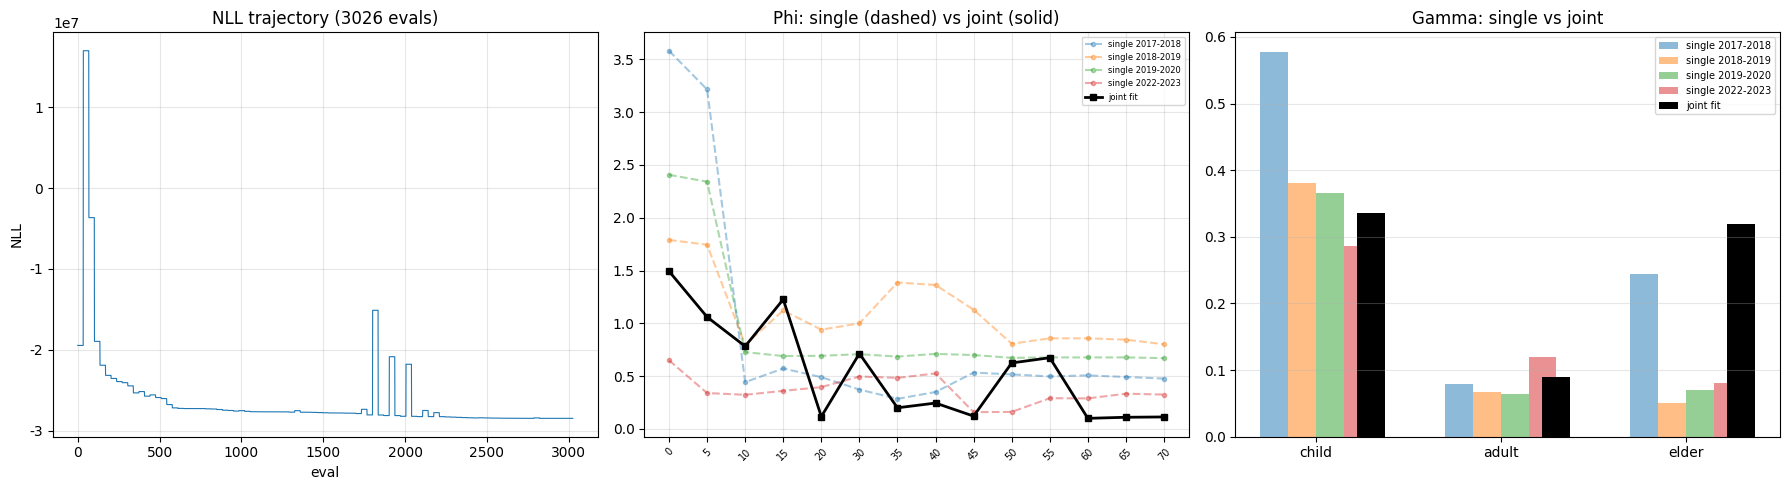

In [11]:
# NLL trajectory + comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# NLL trajectory
ax = axes[0]
ax.plot(nll_history, lw=0.8)
ax.set_xlabel("eval"); ax.set_ylabel("NLL")
ax.set_title(f"NLL trajectory ({len(nll_history)} evals)"); ax.grid(alpha=0.3)

# Phi comparison: single-season (4 lines) vs joint (1 line)
ax = axes[1]
for si, s in enumerate(SEASONS):
    ax.plot(range(14), single_vecs[s][4:18], "o--", ms=3, alpha=0.4, label=f"single {s}")
ax.plot(range(14), phi_fit, "s-", ms=5, color="black", lw=2, label="joint fit")
ax.set_xticks(range(14))
ax.set_xticklabels([f"{a*5}" for a in range(15) if a != 5], fontsize=7, rotation=45)
ax.set_title("Phi: single (dashed) vs joint (solid)"); ax.legend(fontsize=6); ax.grid(alpha=0.3)

# Gamma comparison
ax = axes[2]
x = np.arange(3)
w = 0.15
for si, s in enumerate(SEASONS):
    ax.bar(x + (si-1.5)*w, single_vecs[s][18:21], width=w, alpha=0.5, label=f"single {s}")
ax.bar(x + 2*w, gamma_fit, width=w, color="black", label="joint fit")
ax.set_xticks(x); ax.set_xticklabels(["child", "adult", "elder"])
ax.set_title("Gamma: single vs joint"); ax.legend(fontsize=7); ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(OUTDIR / "multi_season_joint_comparison.png", dpi=150, bbox_inches="tight")
print("saved multi_season_joint_comparison.png"); plt.show()


In [12]:
# Save result
result_dict = {
    "metadata": {
        "method": "L-BFGS-B multi-season joint",
        "seasons": SEASONS, "dimension": N_TOTAL,
        "wall_time_min": round(wall / 60, 1),
        "n_evals": eval_count[0],
        "success": bool(sol.success), "message": str(sol.message),
    },
    "nll": {"initial": float(init_nll), "final": float(sol.fun),
            "per_season_final": {s: float(v) for s, v in final_breakdown.items()}},
    "shared": {
        "phi": phi_fit.tolist(),
        "gamma_child": float(gamma_fit[0]),
        "gamma_adult": float(gamma_fit[1]),
        "gamma_elder": float(gamma_fit[2]),
    },
    "per_season": {
        s: {"beta": betas_fit[s].tolist(),
            "age_bias": {ag: float(age_bias[s][ag]) for ag in HIRA_AGE_GROUPS}}
        for s in SEASONS
    },
    "vector_33": best.tolist(),
}
out_path = OUTDIR / "multi_season_joint_v1.json"
with open(out_path, "w") as f:
    json.dump(result_dict, f, indent=2)
print(f"saved {out_path}")

print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"Wall time: {wall/60:.1f} min, {eval_count[0]} evals, success={sol.success}")
print(f"NLL: {init_nll:,.0f} -> {sol.fun:,.0f}")
print(f"Shared gamma: child={gamma_fit[0]:.4f} adult={gamma_fit[1]:.4f} elder={gamma_fit[2]:.4f}")
print(f"Phi range: [{phi_fit.min():.3f}, {phi_fit.max():.3f}]")


saved ../outputs/calibration/multi_season_joint_v1.json

SUMMARY
Wall time: 281.0 min, 3026 evals, success=True
NLL: -16,766,738 -> -28,469,430
Shared gamma: child=0.3362 adult=0.0892 elder=0.3198
Phi range: [0.100, 1.493]
